In [1]:
from datetime import datetime
import logging
from pathlib import Path
import shutil
import sys
from langgraph.types import Command

from deep_notes_ai.config.logging_setup import configure_logging
from deep_notes_ai.config.settings import Settings
from deep_notes_ai.langgraph_pipeline.graph import build_graph
from deep_notes_ai.domain.models import ContentMetadata, ProcessingContext, SourceType

from IPython import get_ipython
from IPython.display import Image, display

from deep_notes_ai.services.llm_monitor_service import LLMMonitorService


def _persist_pipeline_reports(
    logger_name: str,
    log_file_path: Path,
    reports_dir: Path,
    monitor_service: LLMMonitorService | None = None,
) -> None:

    if monitor_service is not None:
        print("\n[INFO] Saving LLM monitoring report.")

        try:
            monitor_service.save_reports(reports_dir)
            print("[INFO] LLM monitoring report saved successfully.")

        except Exception as exc:
            print(
                f"[ERROR] LLM monitoring report failed: {exc}",
                file=sys.stderr,
            )

    print("\n[INFO] Moving pipeline log.")

    try:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        destination_log = (
            reports_dir
            / f"pipeline_{timestamp}.log"
        )

        logger = logging.getLogger(logger_name)

        for handler in logger.handlers:
            handler.flush()
            handler.close()

        if log_file_path.exists():
            destination_log.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            shutil.move(
                log_file_path,
                destination_log,
            )

            print(
                f"[INFO] Pipeline log moved to: {destination_log}"
            )

        else:
            print(
                f"[ERROR] Pipeline log not found: {log_file_path}",
                file=sys.stderr,
            )

    except Exception as exc:
        print(
            f"[ERROR] Moving pipeline log failed: {exc}",
            file=sys.stderr,
        )


def _collect_breakpoint_selection(interrupt_value: dict) -> dict:
    summary: dict = interrupt_value.get("summary", {})
    chapters: list[str] = interrupt_value.get("chapters", [])
    instructions: list[str] = interrupt_value.get("instructions", [])

    total_tokens: int = summary.get("total_tokens", 0)
    max_tokens: int = summary.get("max_tokens_per_part", 50_000)
    total_chapters: int = summary.get("total_chapters", len(chapters))

    print("\n" + "─" * 72)
    print("  ⚡  Multi-Part Transcript Processing")
    print("─" * 72)
    print(f"  Transcript size : {total_tokens:,} tokens")
    print(f"  Maximum per part: {max_tokens:,} tokens")
    print(f"  Chapters found  : {total_chapters}")
    print("─" * 72)

    print("\n  Available chapters:\n")

    for chapter in chapters:
        print(f"    {chapter}")

    print("\n" + "─" * 72)

    print("  Instructions:\n")
    for instruction in instructions:
        print(f"    • {instruction}")

    print("─" * 72)

    valid_indices = set(range(total_chapters))

    while True:
        raw = input(
            "\n  Enter chapter indices that should START a new transcript part\n"
            "  (comma-separated, e.g. 3,7,12)\n\n"
            "  Selection: "
        ).strip()

        if not raw:
            print("\n  ⚠  Please enter at least one chapter index.\n")
            continue

        try:
            selected = sorted(
                {
                    int(value.strip())
                    for value in raw.split(",")
                    if value.strip()
                }
            )
        except ValueError:
            print(
                "\n  ⚠  Invalid input. Please enter only integer values "
                "separated by commas.\n"
            )
            continue

        invalid = [
            index
            for index in selected
            if index not in valid_indices
        ]

        if invalid:
            print(
                f"\n  ⚠  Invalid chapter indices: {invalid}\n"
                f"  Valid range: 0-{total_chapters - 1}\n"
            )
            continue

        print("\n  ✓ Selected breakpoint chapters:\n")

        for index in selected:
            print(f"    {chapters[index]}")

        print("\n" + "─" * 72 + "\n")

        return {
            "selected_indices": selected,
        }

def run_pipeline(
    url: str,
    source_type: SourceType
):
    
    try:
        settings = Settings()
    except Exception as exc:
        print(f"[ERROR] Failed to load settings: {exc}", file=sys.stderr)
        return 1

    logger_name = "deep_notes_ai"
    log_file_path = configure_logging(
        logger_name=logger_name,
        log_level=settings.log_level,
        structured=settings.enable_structured_logging,
        log_dir=settings.logs_dir,
    )

    try:
        graph, monitor_service = build_graph(settings)
        
        if get_ipython() is not None:
            display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print(f"[ERROR] Failed to build pipeline graph: {exc}", file=sys.stderr)
        return 1

    initial_state = {
        "source": url,
        "source_type": source_type,
        "pipeline_complete": False,
        "error_message": None,
    }

    print(f"[INFO] Starting pipeline for source: {url} (type: {source_type})")
    try:
        config: dict = {"configurable": {"thread_id": url}}

        result = graph.invoke(initial_state, config=config)

        while isinstance(result, dict) and result.get("__interrupt__"):
            print("[INFO] Pipeline interrupted.")
            interrupt_events = result["__interrupt__"]
            interrupt_value = interrupt_events[0].value
            user_input = _collect_breakpoint_selection(interrupt_value)
            result = graph.invoke(Command(resume=user_input), config=config)

        final_state = result
        print("[INFO] Pipeline completed successfully.")
    except Exception as exc:
        print(f"[ERROR] Pipeline failed: {exc}", file=sys.stderr)
        _persist_pipeline_reports(
            logger_name=logger_name,
            log_file_path=log_file_path,
            reports_dir=Path("pipeline_crash_logs"),
            monitor_service=monitor_service
        )
        return -1
    
    if not final_state.get("pipeline_complete"):
        error_msg = final_state.get("error_message", "Unknown error")
        print(f"[ERROR] Pipeline did not complete successfully: {error_msg}", file=sys.stderr)

    print("\n[INFO] Pipeline Final State")
    print("─" * 72)

    metadata: ContentMetadata = final_state.get("metadata")
    processing_context: ProcessingContext = final_state.get("processing_context")

    print(f"  Source              : {final_state.get('source')}")
    print(f"  Source Type         : {final_state.get('source_type')}")
    print(f"  Content Base Dir    : {final_state.get('content_base_dir')}")

    if metadata is not None:
        print(f"  Content ID          : {metadata.id}")
        print(f"  Content Title       : {metadata.title}")
        print(f"  Author Name         : {metadata.author}")
        print(f"  Upload Date         : {metadata.upload_date}")
        print(f"  Content URL         : {metadata.url}")
    else:
        print("  Metadata            : <not available>")

    print(
        f"  Chapters            : "
        f"{len(final_state.get('chapters', []))}"
    )

    if processing_context is not None:
        print(f"  Processing Mode     : {processing_context.processing_mode}")
        print(f"  Total Parts         : {processing_context.total_parts}")
        print(f"  Current Part        : {processing_context.current_part}")
    else:
        print("  Processing Context  : <not available>")

    print(f"  Pipeline Complete   : {final_state.get('pipeline_complete')}")
    print(f"  Error Message       : {final_state.get('error_message')}")

    print("─" * 72)

    reports_dir: Path = final_state.get("content_base_dir") / "logs"
    _persist_pipeline_reports(
        logger_name=logger_name,
        log_file_path=log_file_path,
        reports_dir=reports_dir,
        monitor_service=monitor_service
    )

    return 0

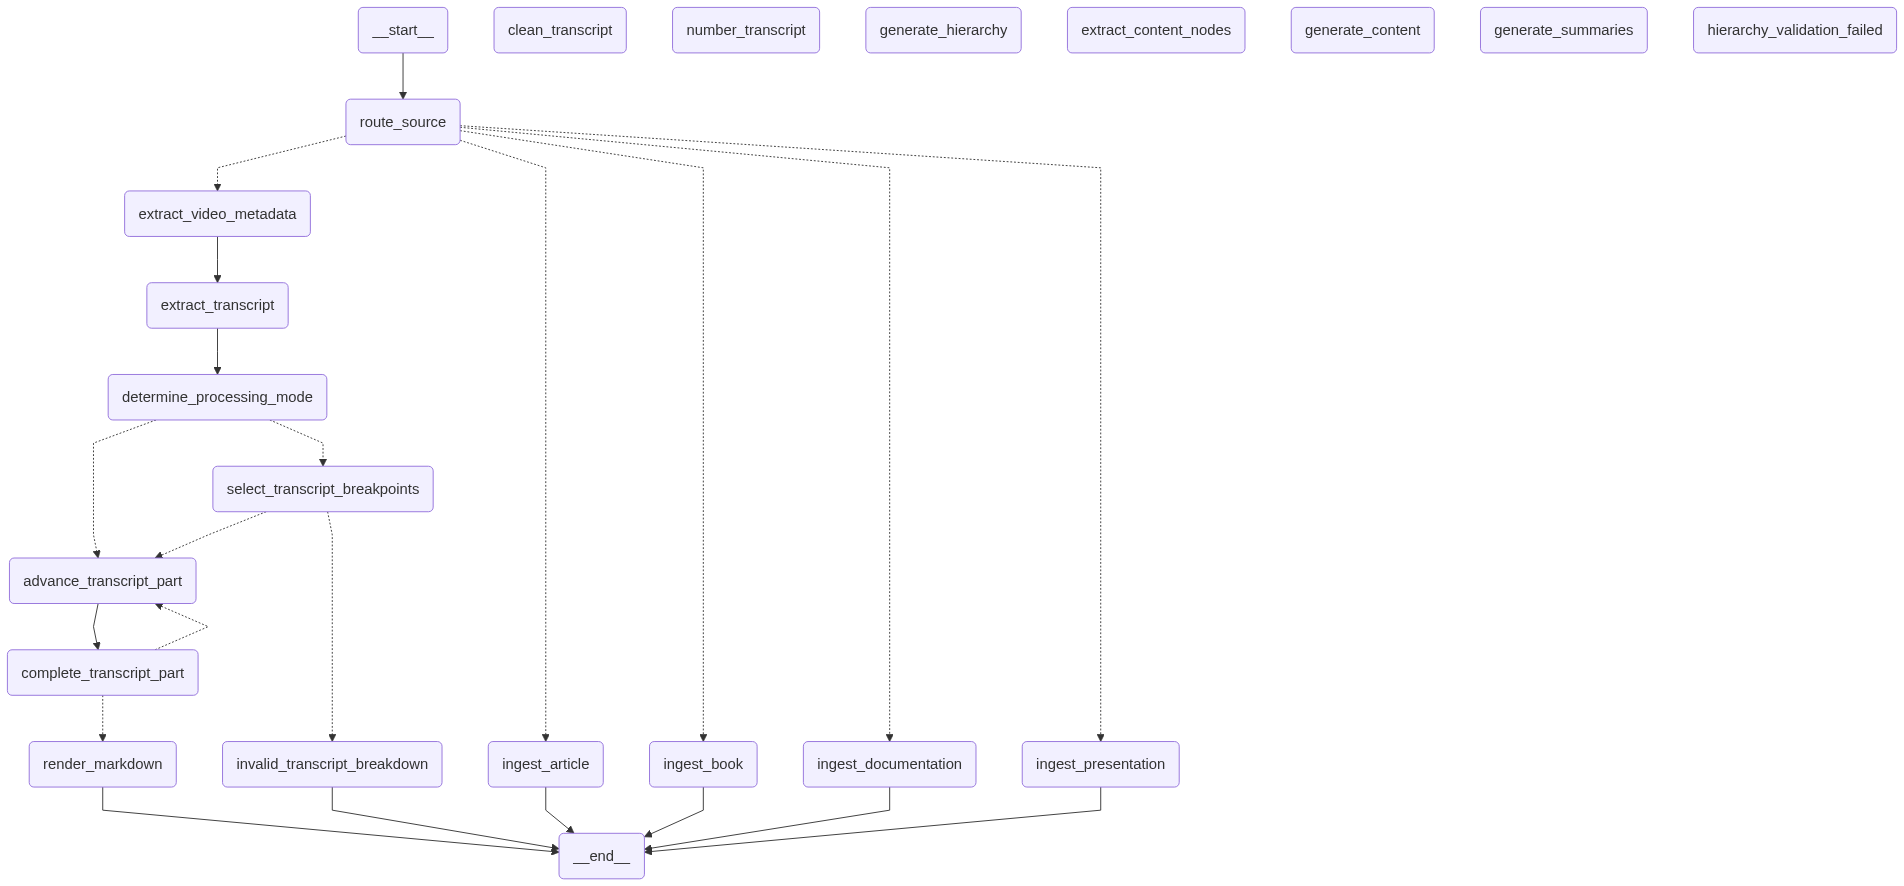

[INFO] Starting pipeline for source: https://www.youtube.com/watch?v=upblQZigz0U (type: youtube)
────────────────────────────────────────────────
⟳ Extracting Video Metadata
✓ Extracting Video Metadata
⟳ Downloading Transcript
✓ Downloading Transcript
⟳ Determining Processing Mode
· Transcript contains 74,324 tokens (limit 50,000). Multi-part processing required.
⟳ Waiting for User Selection
[INFO] Pipeline interrupted.

────────────────────────────────────────────────────────────────────────
  ⚡  Multi-Part Transcript Processing
────────────────────────────────────────────────────────────────────────
  Transcript size : 74,324 tokens
  Maximum per part: 50,000 tokens
  Chapters found  : 20
────────────────────────────────────────────────────────────────────────

  Available chapters:

    [00] 00:00:00 |  2,927 tokens | Introduction
    [01] 00:17:13 |  3,110 tokens | What is Agentic AI?
    [02] 00:36:19 |  1,644 tokens | Agentic AI vs Generative AI
    [03] 00:46:07 |  1,092 tokens 

Deserializing unregistered type deep_notes_ai.domain.models.SourceType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('deep_notes_ai.domain.models', 'SourceType')]
Deserializing unregistered type deep_notes_ai.domain.models.VideoMetadata from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('deep_notes_ai.domain.models', 'VideoMetadata')]
Deserializing unregistered type deep_notes_ai.domain.models.ChapterTranscript from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('deep_notes_ai.domain.models', 'ChapterTranscript')]
Deserializing unregistered type deep_notes_ai.domain.models.TranscriptProcessingMode from checkpoint. This will be blocked in a future ve


  ✓ Selected breakpoint chapters:

    [08] 03:09:37 |  2,243 tokens | Transformers Neural Networks Explained

────────────────────────────────────────────────────────────────────────

⟳ Waiting for User Selection
✓ Waiting for User Selection
⟳ Preparing Transcript Part
· Processing part 1/2
· Raw content restored from cache
⟳ Completing Transcript Part
· Completed part 1/2. Next: part 2/2.
⟳ Preparing Transcript Part
· Processing part 2/2
· Raw content restored from cache
⟳ Completing Transcript Part
✓ Completing Transcript Part
⟳ Rendering Markdown
✓ Rendering Markdown
· Pipeline finished — notes ready.
[INFO] Pipeline completed successfully.

[INFO] Pipeline Final State
────────────────────────────────────────────────────────────────────────
  Source              : https://www.youtube.com/watch?v=upblQZigz0U
  Source Type         : youtube
  Content Base Dir    : /Users/govind/github_repos/deep-notes-knowledge-base/youtube/upblQZigz0U
  Content ID          : upblQZigz0U
  Content T

0

In [ ]:
run_pipeline(
    url="https://www.youtube.com/watch?v=upblQZigz0U",
    source_type=SourceType.YOUTUBE
)


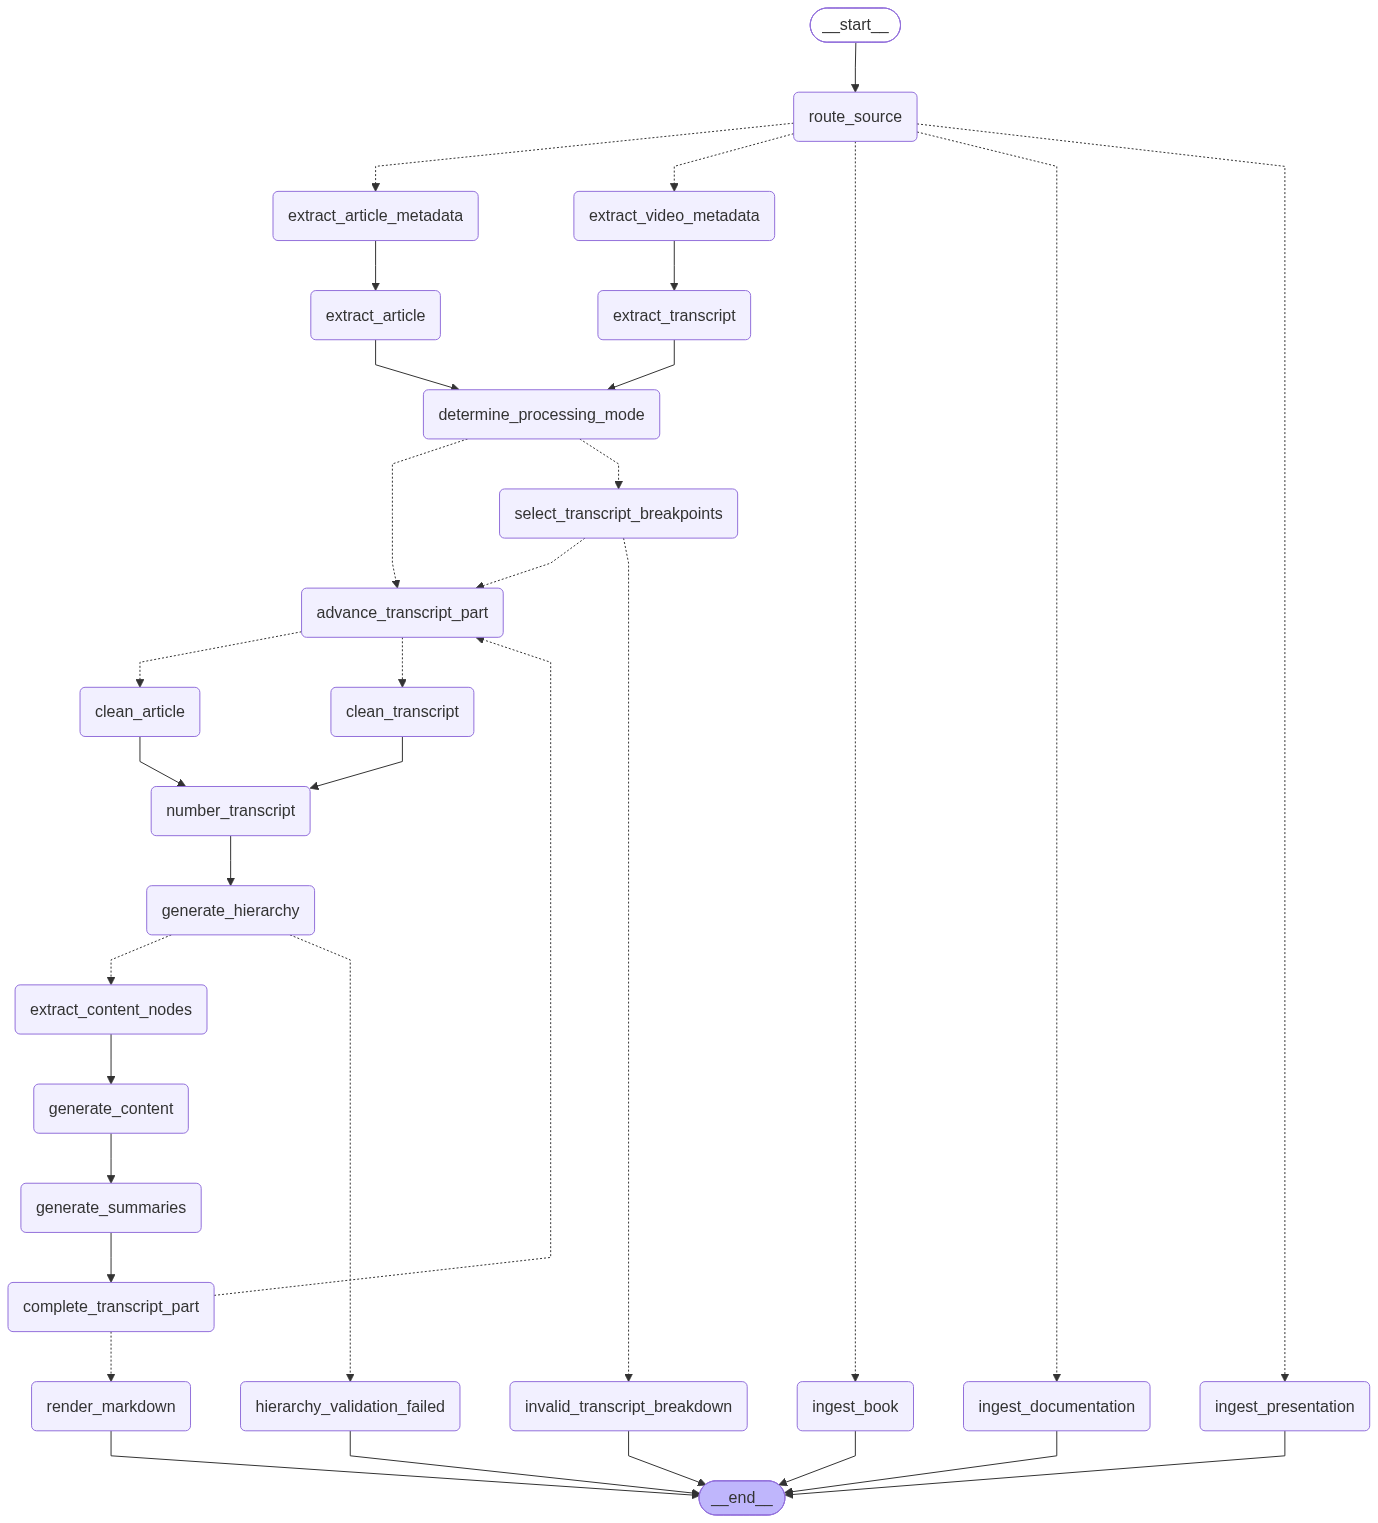

[INFO] Starting pipeline for source: https://jalammar.github.io/illustrated-word2vec/ (type: article)
────────────────────────────────────────────────
⟳ Extracting Article Metadata
✓ Extracting Article Metadata
⟳ Extracting Article
✓ Extracting Article
⟳ Determining Processing Mode
✓ Determining Processing Mode
⟳ Preparing Transcript Part
· Processing part 1/1
✓ Preparing Transcript Part
⟳ Cleaning Transcript
✓ Cleaning Transcript
⟳ Numbering Transcript
✓ Numbering Transcript
⟳ Generating Topic Hierarchy
✓ Generating Topic Hierarchy
⟳ Extracting Content Nodes
✓ Extracting Content Nodes
⟳ Generating Structured Content
    Partition 2 / 2  (2 / 2)                    
✓ Generating Structured Content
⟳ Generating Summaries
    Partition 2 / 2  (2 / 2)                    
✓ Generating Summaries
⟳ Completing Transcript Part
✓ Completing Transcript Part
⟳ Rendering Markdown
✓ Rendering Markdown
· Pipeline finished — notes ready.
[INFO] Pipeline completed successfully.

[INFO] Pipeline Final S

0

In [2]:
run_pipeline(
    url="https://jalammar.github.io/illustrated-word2vec/",
    source_type=SourceType.ARTICLE
)

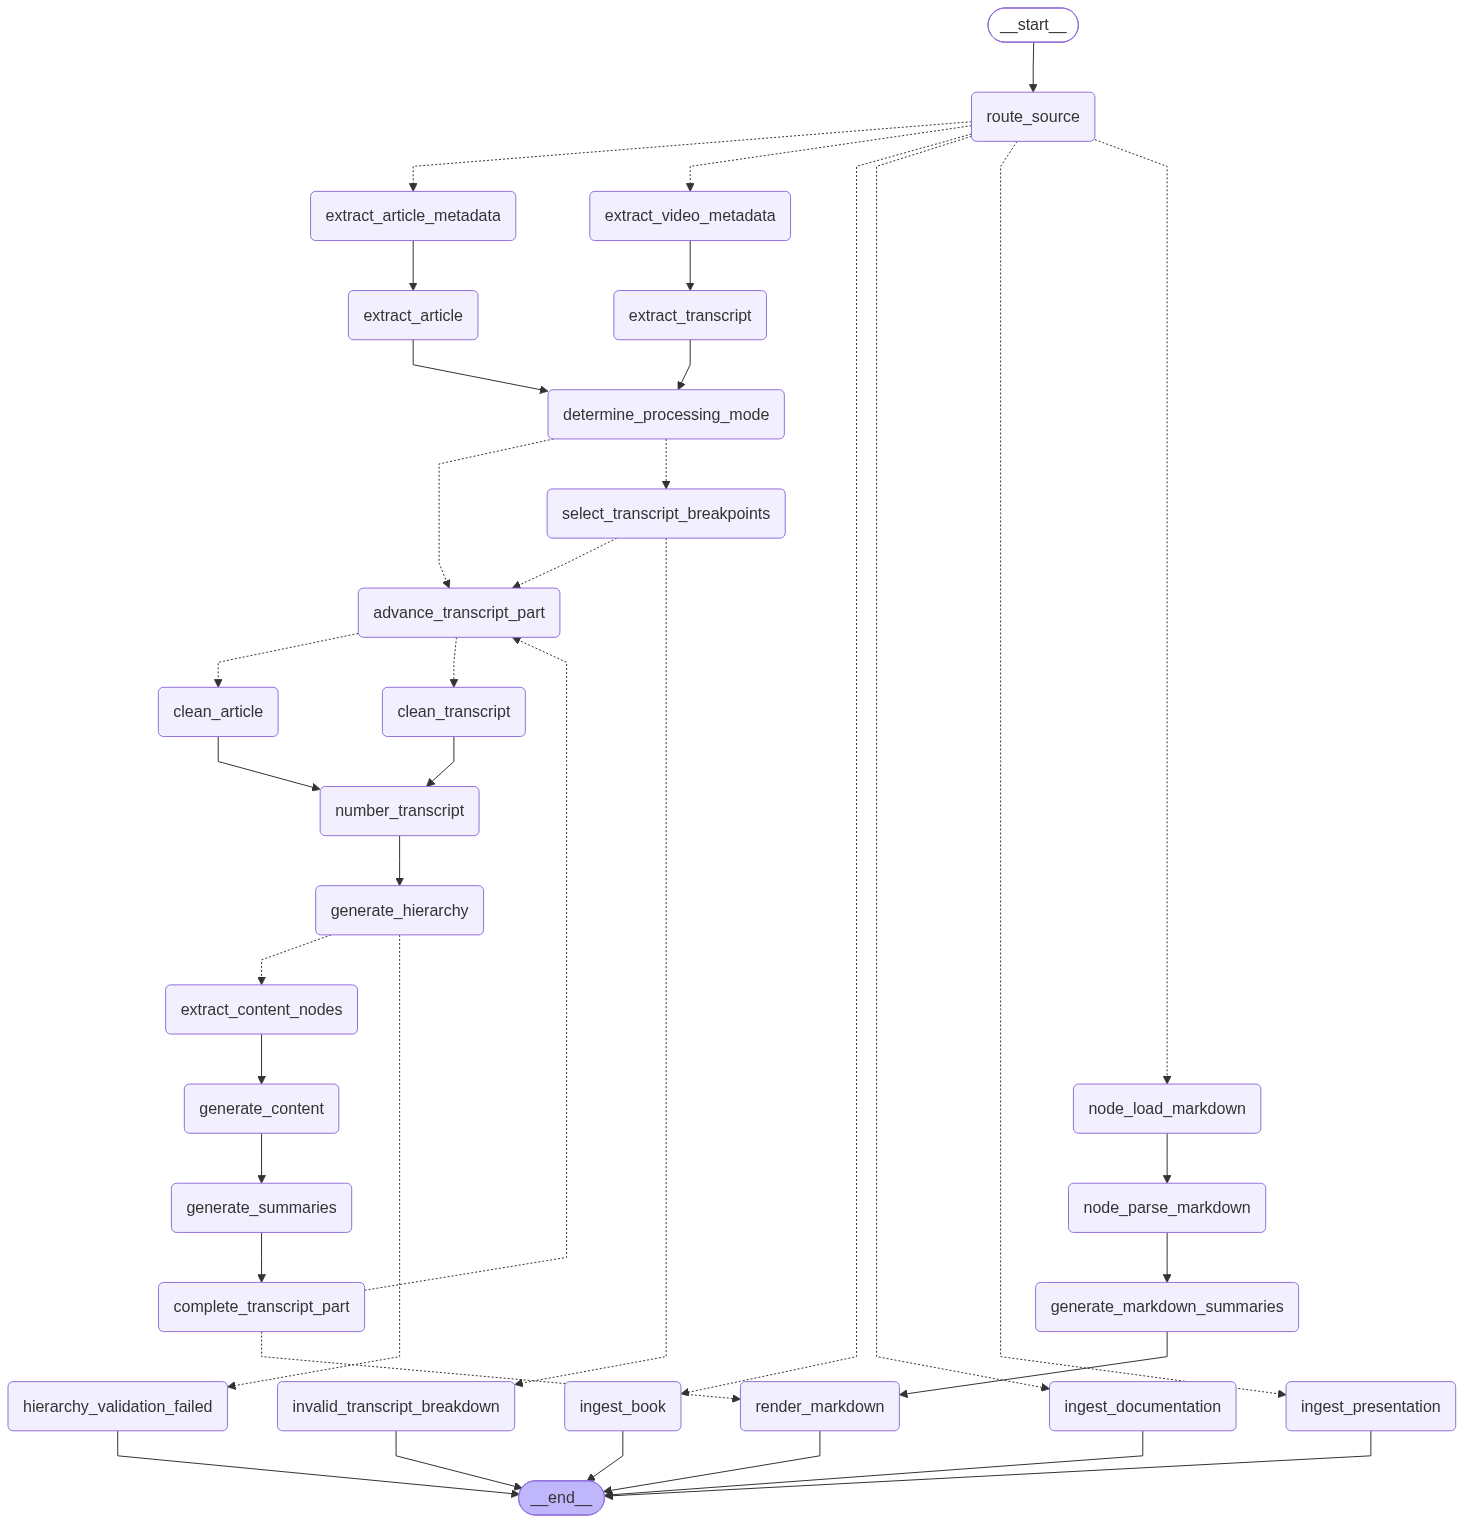

[INFO] Starting pipeline for source: https://docs.langchain.com/oss/python/integrations/splitters.md (type: markdown)
────────────────────────────────────────────────
⟳ Loading Markdown
✓ Loading Markdown
⟳ Parsing Markdown
✓ Parsing Markdown
⟳ Generating Summaries
    Partition 1 / 1  (1 / 1)                    
✓ Generating Summaries
⟳ Rendering Markdown
✓ Rendering Markdown
· Pipeline finished — notes ready.
[INFO] Pipeline completed successfully.

[INFO] Pipeline Final State
────────────────────────────────────────────────────────────────────────
  Source              : https://docs.langchain.com/oss/python/integrations/splitters.md
  Source Type         : markdown
  Content Base Dir    : /Users/govind/github_repos/deep-notes-knowledge-base/markdown/4bca0b665ddc8dd2c09ad1062ebc9a6ccabe781f5cfe8d2a662ac927c2cdae44
  Content ID          : 4bca0b665ddc8dd2c09ad1062ebc9a6ccabe781f5cfe8d2a662ac927c2cdae44
  Content Title       : Text splitter integrations
  Author Name         : 
  Uplo

0

In [4]:
path = "/Users/govind/Downloads/splitters.md"
url = "https://docs.langchain.com/oss/python/integrations/splitters.md"

run_pipeline(
    url=url,
    source_type=SourceType.MARKDOWN
)

In [1]:
from deep_notes_ai.services.article.article_download_service import ArticleDownloadService
from deep_notes_ai.config.settings import Settings
from deep_notes_ai.services.article.article_extraction_service import ArticleExtractionService
from deep_notes_ai.services.article.article_metadata_service import ArticleMetadataService
from deep_notes_ai.services.article.markdown_structure_service import MarkdownStructureService
from deep_notes_ai.services.tokenizer_service import TokenizerService

url = "https://docs.langchain.com/oss/python/integrations/splitters"
settings = Settings()
download_service = ArticleDownloadService(settings=settings)
metadata_service = ArticleMetadataService()
markdown_service = MarkdownStructureService()
tokenizer_service = TokenizerService(model_name=settings.article_cleaning_model_name)
extraction_service = ArticleExtractionService(markdown_service, tokenizer_service)
html = download_service.download(url)
metadata = metadata_service.build_metadata(url=url, html=html)
chapters = extraction_service.extract_chapters(metadata.raw_html)


In [2]:
from pprint import pprint

pprint(metadata.dict())

{'author': '',
 'description': 'Integrate with text splitters using LangChain.',
 'id': '0385b9c008584c9a',
 'raw_html': '<!DOCTYPE html><html lang="en" '
             'class="inter_1d81deff-module__CYM0aG__variable '
             'papermono_89c757f2-module__6aS5zq__variable dark" '
             'data-banner-state="visible" data-assistant-state="closed" '
             'data-page-mode="none" data-current-path="/"><head><meta '
             'charSet="utf-8"/><meta name="viewport" '
             'content="width=device-width, initial-scale=1, '
             'viewport-fit=cover"/><link rel="preload" as="image" '
             'href="https://mintcdn.com/langchain-5e9cc07a/nQm-sjd_MByLhgeW/images/brand/langchain-docs-dark-blue.png?fit=max&amp;auto=format&amp;n=nQm-sjd_MByLhgeW&amp;q=85&amp;s=5babf1a1962208fd7eed942fa2432ecb"/><link '
             'rel="preload" as="image" '
             'href="https://mintcdn.com/langchain-5e9cc07a/nQm-sjd_MByLhgeW/images/brand/langchain-docs-light-blue.png?fi

/var/folders/k8/l0_xs3pn72v3l3dpmr9q86pm0000gn/T/ipykernel_64155/1602960819.py:3: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  pprint(metadata.dict())


In [3]:
pprint(chapters)

[ChapterTranscript(title='# Introduction',
                   display='00:00:00',
                   transcript='# Introduction\n'
                              '\n'
                              '**Text splitters**break large docs into smaller '
                              'chunks that will be retrievable individually '
                              'and fit within model context window limit. '
                              'There are several strategies for splitting '
                              'documents, each with its own advantages.',
                   tokens=42),
 ChapterTranscript(title='## Text structure-based',
                   display='00:00:21',
                   transcript='## Text structure-based\n'
                              '\n'
                              'Text is naturally organized into hierarchical '
                              'units such as paragraphs, sentences, and words. '
                              'We can leverage this inherent structure to 

In [2]:
from deep_notes_ai.services.markdown.markdown_loader_service import MarkdownLoaderService
from deep_notes_ai.services.markdown.markdown_metadata_service import MarkdownMetadataService
from deep_notes_ai.services.markdown.markdown_parser_service import MarkdownParserService
from deep_notes_ai.services.persistence_service import PersistenceService

path = "/Users/govind/Downloads/KiteWatch_PRD_latest.md"
url = "https://docs.langchain.com/oss/python/integrations/splitters.md"
persistence_service = PersistenceService()
markdown_loader = MarkdownLoaderService(persistence_service=persistence_service)
markdown_metadata_service = MarkdownMetadataService()
markdown_parser = MarkdownParserService()
content = markdown_loader.load(source=url)
metadata = markdown_metadata_service.build_metadata(source=url, markdown=content)
hierarchy, content_node = markdown_parser.parse_document(metadata.raw_content)

In [3]:
from pprint import pprint

pprint(hierarchy)
pprint(content_node)

[TitleNode(type='topic',
           name='Text splitter integrations',
           subtopics=[ContentNode(type='content',
                                  id='8a1c6c60-c68c-4df7-ac1f-b1120a18fb99'),
                      TitleNode(type='topic',
                                name='Text structure-based',
                                subtopics=[ContentNode(type='content',
                                                       id='453b507c-8fb6-4e87-ad74-5359a9d7515a')]),
                      TitleNode(type='topic',
                                name='Length-based',
                                subtopics=[ContentNode(type='content',
                                                       id='023e9ec1-3f68-4477-9eef-21032a6010d6')]),
                      TitleNode(type='topic',
                                name='Document structure-based',
                                subtopics=[ContentNode(type='content',
                                                       id='3ab57c6c-c

In [5]:
from deep_notes_ai.services.persistence_service import PersistenceService

persistence_service = PersistenceService()
path = Path("/Users/govind/github_repos/deep-notes-knowledge-base/markdown/id1123/")
persistence_service.clear_directory(path)

In [4]:
from deep_notes_ai.services.llm_service import LLMService
from deep_notes_ai.services.persistence_service import PersistenceService
from deep_notes_ai.services.pricing_service import PricingService
from deep_notes_ai.services.prompt_service import PromptService
from langchain_core.runnables import Runnable


persistence_service = PersistenceService()
prompt_service = PromptService(settings.prompts_dir)
cleaning_prompt = prompt_service.load("article_cleaner")
pricing_service = PricingService()
monitor_service = LLMMonitorService(
    pricing_service=pricing_service,
    persistence_service=persistence_service,
)
llm_service = LLMService(settings, monitor_service=monitor_service)
cleaning_model = llm_service.get_chat_model(
    provider=settings.cleaning_model_provider,
    model=settings.cleaning_model_name,
    temperature=settings.cleaning_model_temperature,
    node_name="NODE_CLEAN_TRANSCRIPT",
    operation_name="Transcript Cleaning",
)
cleaning_chain: Runnable = cleaning_prompt | cleaning_model

content = [chapter.transcript for chapter in chapters]

response = cleaning_chain.invoke("\n\n".join(content))

print(response)

content='- “There is in all things a pattern that is part of our universe. It has symmetry, elegance, and grace- those qualities you find always in that which the true artist captures. You can find it in the turning of the seasons, in the way sand trails along a ridge, in the branch clusters of the creosote bush or the pattern of its leaves. We try to copy these patterns in our lives and our society, seeking the rhythms, the dances, the forms that comfort. Yet, it is possible to see peril in the finding of ultimate perfection. It is clear that the ultimate pattern contains it own fixity. In such perfection, all things move toward death.” ~ Dune (1965)\n- I find the concept of embeddings to be one of the most fascinating ideas in machine learning; embeddings are central to many NLP models and services you’ve used (Siri, Google Assistant, Alexa, machine translation, next-word prediction), and recent developments include contextualized word embeddings powering models like BERT and GPT-2.\

In [5]:
pprint(response.content)

('- “There is in all things a pattern that is part of our universe. It has '
 'symmetry, elegance, and grace- those qualities you find always in that which '
 'the true artist captures. You can find it in the turning of the seasons, in '
 'the way sand trails along a ridge, in the branch clusters of the creosote '
 'bush or the pattern of its leaves. We try to copy these patterns in our '
 'lives and our society, seeking the rhythms, the dances, the forms that '
 'comfort. Yet, it is possible to see peril in the finding of ultimate '
 'perfection. It is clear that the ultimate pattern contains it own fixity. In '
 'such perfection, all things move toward death.” ~ Dune (1965)\n'
 '- I find the concept of embeddings to be one of the most fascinating ideas '
 'in machine learning; embeddings are central to many NLP models and services '
 'you’ve used (Siri, Google Assistant, Alexa, machine translation, next-word '
 'prediction), and recent developments include contextualized word embeddi

In [9]:
pprint("\n\n".join(content))

('# The Illustrated Word2vec\n'
 '\n'
 'Discussions:\n'
 'Hacker News (347 points, 37 comments), Reddit r/MachineLearning (151 points, '
 '19 comments)\n'
 '\n'
 'Translations: Chinese (Simplified), French, Korean, Portuguese, Russian\n'
 '\n'
 '“There is in all things a pattern that is part of our universe. It has '
 'symmetry, elegance, and grace- those qualities you find always in that which '
 'the true artist captures. You can find it in the turning of the seasons, in '
 'the way sand trails along a ridge, in the branch clusters of the creosote '
 'bush or the pattern of its leaves.\n'
 '\n'
 'We try to copy these patterns in our lives and our society, seeking the '
 'rhythms, the dances, the forms that comfort. Yet, it is possible to see '
 'peril in the finding of ultimate perfection. It is clear that the ultimate '
 'pattern contains it own fixity. In such perfection, all things move toward '
 'death.” ~ Dune (1965)\n'
 '\n'
 'I find the concept of embeddings to be one of the m